   Gender  Age  Height (cm)  Weight (kg)            Occupation  \
0    male   32          175           70     Software Engineer   
1    male   25          182           85  Sales Representative   
2  female   41          160           62                Doctor   
3    male   38          178           79                Lawyer   
4  female   29          165           58      Graphic Designer   

      Education Level Marital Status  Income (USD) Favorite Color  
0     Master's Degree        Married         75000           Blue  
1   Bachelor's Degree         Single         45000          Green  
2    Doctorate Degree        Married        120000         Purple  
3   Bachelor's Degree         Single         90000            Red  
4  Associate's Degree         Single         35000         Yellow  

Shape: (131, 9)

  BINARY CLASSIFICATION  →  Gender (male / female)
Accuracy : 96.30%
              precision    recall  f1-score   support

      Female       1.00      0.93      0.96        14

C:\Users\siddh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\siddh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\siddh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

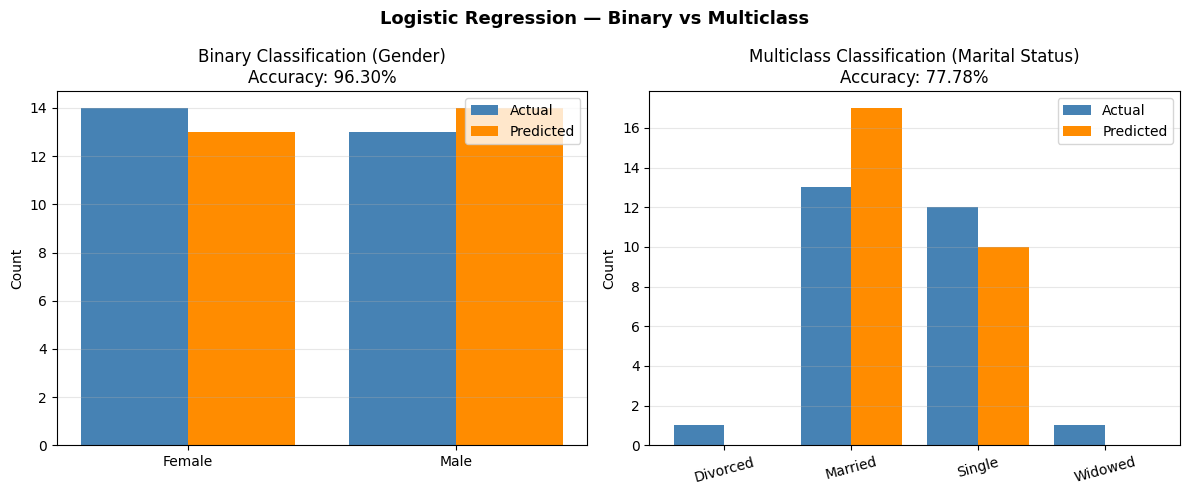

In [39]:
# ============================================================
#   LOGISTIC REGRESSION
#   Binary Classification    → Gender (male / female)
#   Multiclass Classification → Marital Status (4 classes)
#   Dataset: Gender
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Load & Clean Dataset
df = pd.read_csv("gender-ex-5.csv")
df.columns = df.columns.str.strip()          # remove leading/trailing spaces
df = df.drop(columns=["Unnamed: 9"])         # drop empty column
for col in df.columns:
    if df[col].dtype == object or str(df[col].dtype) == "str":
        df[col] = df[col].str.strip()        # strip spaces in values

print(df.head())
print(f"\nShape: {df.shape}")

# 2. Encode Categorical Features
le = LabelEncoder()
df["Occupation"]      = le.fit_transform(df["Occupation"])
df["Education Level"] = le.fit_transform(df["Education Level"])
df["Favorite Color"]  = le.fit_transform(df["Favorite Color"])

# Features used for both models
FEATURES = ["Age", "Height (cm)", "Weight (kg)",
            "Occupation", "Education Level", "Income (USD)"]

# ══════════════════════════════════════════════════════════
#   PART A — BINARY CLASSIFICATION  (Gender: male / female)
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  BINARY CLASSIFICATION  →  Gender (male / female)")
print("=" * 55)

X_bin = df[FEATURES]
y_bin = le.fit_transform(df["Gender"])       # male=1, female=0

X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

lr_bin = LogisticRegression(max_iter=1000, random_state=42)
lr_bin.fit(X_train, y_train)
y_pred_bin = lr_bin.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred_bin) * 100:.2f}%")
print(classification_report(y_test, y_pred_bin,
                             target_names=["Female", "Male"]))

# ══════════════════════════════════════════════════════════
#   PART B — MULTICLASS CLASSIFICATION  (Marital Status)
# ══════════════════════════════════════════════════════════
print("=" * 55)
print("  MULTICLASS CLASSIFICATION  →  Marital Status")
print("=" * 55)

X_mc = df[FEATURES]
y_mc = le.fit_transform(df["Marital Status"])
classes = le.classes_
print(f"Classes: {classes}\n")

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42)

scaler2 = StandardScaler()
X_train_m = scaler2.fit_transform(X_train_m)
X_test_m  = scaler2.transform(X_test_m)

lr_mc = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)
lr_mc.fit(X_train_m, y_train_m)
y_pred_mc = lr_mc.predict(X_test_m)

print(f"Accuracy : {accuracy_score(y_test_m, y_pred_mc) * 100:.2f}%")
print(classification_report(y_test_m, y_pred_mc, target_names=classes))

# ══════════════════════════════════════════════════════════
#   COMPARISON TABLE
# ══════════════════════════════════════════════════════════
print("=" * 55)
print("            MODEL COMPARISON")
print("=" * 55)
print(f"  {'Model':<40} {'Accuracy':>10}")
print(f"  {'-'*40} {'-'*10}")
print(f"  {'Binary  (Gender)':<40} "
      f"{accuracy_score(y_test, y_pred_bin)*100:>9.2f}%")
print(f"  {'Multiclass (Marital Status)':<40} "
      f"{accuracy_score(y_test_m, y_pred_mc)*100:>9.2f}%")

# ══════════════════════════════════════════════════════════
#   PLOTS
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Logistic Regression — Binary vs Multiclass", fontsize=13, fontweight='bold')

# Plot 1 — Binary: Actual vs Predicted counts
binary_labels = ["Female", "Male"]
actual_counts  = [sum(y_test == i) for i in range(2)]
predict_counts = [sum(y_pred_bin == i) for i in range(2)]
x = range(2)
axes[0].bar([i - 0.2 for i in x], actual_counts,  width=0.4, label='Actual',    color='steelblue')
axes[0].bar([i + 0.2 for i in x], predict_counts, width=0.4, label='Predicted', color='darkorange')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(binary_labels)
axes[0].set_title(f"Binary Classification (Gender)\nAccuracy: {accuracy_score(y_test, y_pred_bin)*100:.2f}%")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — Multiclass: Actual vs Predicted counts
actual_mc  = [sum(y_test_m == i) for i in range(len(classes))]
predict_mc = [sum(y_pred_mc == i) for i in range(len(classes))]
x2 = range(len(classes))
axes[1].bar([i - 0.2 for i in x2], actual_mc,  width=0.4, label='Actual',    color='steelblue')
axes[1].bar([i + 0.2 for i in x2], predict_mc, width=0.4, label='Predicted', color='darkorange')
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(classes, rotation=15)
axes[1].set_title(f"Multiclass Classification (Marital Status)\nAccuracy: {accuracy_score(y_test_m, y_pred_mc)*100:.2f}%")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 